In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons
import numpy as np
from tqdm import tqdm

from cccaatl_ml.core.tensor import Tensor, enable_autograd
import cccaatl_ml.core.layer as nn
import cccaatl_ml.core.losses as L 
import cccaatl_ml.core.activations as F 
import cccaatl_ml.core.dataloader as data

enable_autograd()

In [3]:
a = Tensor(np.array([1.0, 2.0, 3.0]), requires_grad=True)
b = Tensor(np.array([4.0, 5.0, 6.0]), requires_grad=False)
y = (a + b) * a
y.backward(np.ones(3))
assert np.allclose(a.grad, 2 * a._array + b._array)
#assert np.allclose(b.grad, a._array)


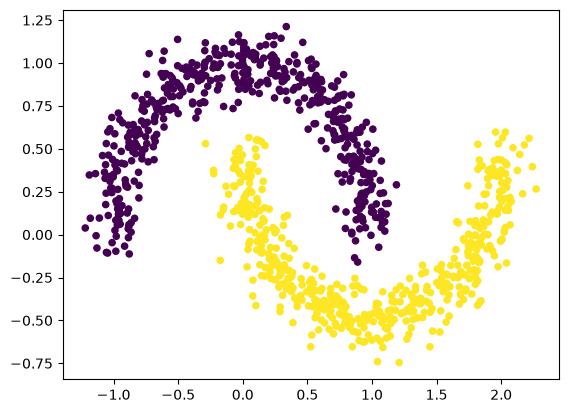

In [58]:
X, Y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X = Tensor(X.astype(np.float32), requires_grad=True)
Y = Tensor(Y.astype(np.int32))
plt.scatter(X._array[:, 0], X._array[:,1], c=Y._array, cmap='viridis', s=20)
plt.show()

In [59]:
# create Dataset from the moon dataset and pass it to Dataloader
dataset = data.TensorDataset(X, Y)
loader = data.DataLoader(dataset, batch_size=4, shuffle=True)
batch_X, batch_Y = next(iter(loader))

In [60]:
batch_X._array, batch_Y._array

(array([[ 1.0110469 , -0.506944  ],
        [ 0.87744313,  0.08639556],
        [-0.18753234,  1.0466757 ],
        [ 1.8198314 ,  0.52638674]], dtype=float32),
 array([1, 0, 0, 1], dtype=int32))

In [76]:
MLP = nn.Sequential( 
    [
        nn.Linear(2, 7), 
        F.ReLU(), 
        nn.Linear(7, 7), 
        nn.Dropout(0.01), 
        F.ReLU(), 
        nn.Linear(7,2)
    ]
)
[param._array for param in MLP.parameters()]
MLP.layers[0].weight.requires_grad

True

In [77]:
# Predictions before training should be random
loss_fn = L.CrossEntropyLoss()
out = MLP(batch_X)
loss = loss_fn(out, batch_Y)
loss.backward(1)

ValueError: cannot reshape array of size 7 into shape (4,7)

In [70]:
MLP.layers[5].weight.grad

array([[ 0.26858243, -0.26858243],
       [ 0.        ,  0.        ],
       [ 0.        ,  0.        ],
       [ 0.38751773, -0.38751773],
       [ 0.39351036, -0.39351036],
       [ 0.        ,  0.        ],
       [ 0.10157527, -0.10157527]])

In [25]:
class SGDOptimizer(object): 
    def __init__(self, model_params, step_size): 
        self.model_params = model_params
        self.step_size = step_size

    def zero_grad(self): 
        for param in self.model_params: 
            param.zero_grad()

    def step(self): 
        for param in self.model_params: 
            param._array = param._array - self.step_size * param.grad

optim = SGDOptimizer(MLP.parameters(), 1e-4)

In [26]:
# training loop 
epochs = 100
loss_fn = L.CrossEntropyLoss()
losses = []

for epoch in range(epochs): 
    pbar = tqdm(loader)
    for batch in pbar: 
        batch_X, batch_Y = batch
        optim.zero_grad()
        pred = MLP(batch_X)
        loss = loss_fn(pred, batch_Y)
        loss.backward() 
        losses.append(loss)
        optim.step()

        pbar.set_description(f"epoch: {epoch} loss: {loss._array}")



  0%|                                                                                                                                                                                                                                                       | 0/250 [00:00<?, ?it/s]


TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

In [9]:
MLP.layers[0].weight._array
MLP.layers[0].weight._grad_fn